In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [14]:
df_raw = pd.read_csv("Ecommerce Churn Dataset 2025.csv")
df_raw.head()

,order_id,customer_id,age,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,order_date,unit_price,quantity,purchase_frequency,preferred_category,product_name,category,gender
0,ORD5000,CUST1000,39,PROD200,Canada,01-07-2021,2/21/2023,0,active,8/20/2024,78.21,5,37,Sports,Football,Sports,Female
1,ORD5001,CUST1001,61,PROD201,USA,10/19/2020,12-08-2021,0,active,7/17/2025,64.02,8,35,Sports,Refrigerator,Home,Female
2,ORD5002,CUST1002,26,PROD202,Pakistan,06-10-2023,09-04-2023,3,cancelled,03-12-2025,604.14,2,44,Electronics,Hoodie,Clothing,Female
3,ORD5003,CUST1003,54,PROD203,India,7/30/2023,2/20/2024,4,paused,9/19/2024,84.66,4,1,Sports,Conditioner,Beauty,Male
4,ORD5004,CUST1004,50,PROD204,India,12-09-2020,9/14/2024,0,active,08-08-2024,62.66,7,35,Sports,Smartwatch,Electronics,Male


In [15]:
def parse_mixed_dates(series):
    """Helper function to handle inconsistent date formats."""
    result = pd.Series(index=series.index, dtype='datetime64[ns]')
    mask_slash = series.str.contains('/', na=False)
    result[mask_slash] = pd.to_datetime(series[mask_slash], format='%m/%d/%Y', errors='coerce')
    mask_dash  = series.str.contains('-', na=False)
    result[mask_dash]  = pd.to_datetime(series[mask_dash], format='%d-%m-%Y', errors='coerce')
    return result

def preprocess_data(df):
    """One-stop function for cleaning, standardization, and advanced feature engineering."""
    df_proc = df.copy()

    # 1. Date Parsing & Anomaly Treatment
    date_cols = ['signup_date', 'last_purchase_date', 'order_date']
    for col in date_cols:
        df_proc[col] = parse_mixed_dates(df_proc[col])

    # Catch Obvious "Time-Travel" Typos (Pinned for reproducibility)
    DATE_OF_ANALYSIS = pd.to_datetime("2026-03-29")
    future_mask = (df_proc['signup_date'] > DATE_OF_ANALYSIS) | \
                  (df_proc['last_purchase_date'] > DATE_OF_ANALYSIS) | \
                  (df_proc['order_date'] > DATE_OF_ANALYSIS)

    # Combined logic check (Negative Tenure or Ghost Orders)
    logical_mask = (df_proc['signup_date'] > df_proc['last_purchase_date']) | \
                   (df_proc['signup_date'] > df_proc['order_date'])

    df_proc = df_proc[~(future_mask | logical_mask)].copy()

    # 2. Categorical Standardization
    cat_cols = ['country', 'subscription_status', 'preferred_category', 'category', 'gender']
    for col in cat_cols:
        if col in df_proc.columns:
            df_proc[col] = df_proc[col].astype(str).str.strip().str.lower()

    # 3. Winsorization (99th Percentile Capping)
    num_cols = ['unit_price', 'quantity', 'purchase_frequency']
    for col in num_cols:
        df_proc[col] = df_proc[col].clip(upper=df_proc[col].quantile(0.99))

    # 4. Target Definition (Drop Paused, Map Binary Churn)
    df_proc = df_proc[df_proc['subscription_status'] != 'paused'].copy()
    df_proc['is_churn'] = (df_proc['subscription_status'] == 'cancelled').astype(int)

    # 5. Feature Engineering: Basic RFM
    # Dynamically anchor to the latest valid transaction
    REFERENCE_DATE = df_proc['last_purchase_date'].max() + pd.Timedelta(days=1)

    df_proc['recency_days'] = (REFERENCE_DATE - df_proc['last_purchase_date']).dt.days
    df_proc['tenure_days'] = (REFERENCE_DATE - df_proc['signup_date']).dt.days
    df_proc['clv_proxy'] = df_proc['unit_price'] * df_proc['quantity'] * df_proc['purchase_frequency']

    # 6. Feature Engineering: Advanced Ratios
    df_proc['recency_tenure_ratio'] = df_proc['recency_days'] / (df_proc['tenure_days'] + 1)
    df_proc['value_velocity'] = df_proc['clv_proxy'] / (df_proc['tenure_days'] + 1)
    df_proc['purchase_intensity'] = df_proc['quantity'] / (df_proc['purchase_frequency'] + 1)

    # 7. Feature Engineering: Risk Flags
    df_proc['is_high_risk_country'] = (df_proc['country'] == 'india').astype(int)
    df_proc['is_high_risk_category'] = df_proc['category'].isin(['beauty', 'home']).astype(int)
    df_proc['is_senior_risk'] = (df_proc['age'] >= 60).astype(int)

    q90_whale = df_proc['clv_proxy'].quantile(0.90)
    df_proc['is_whale_risk'] = (df_proc['clv_proxy'] >= q90_whale).astype(int)

    # 8. Final Column Cleanup
    cols_to_drop = ['signup_date', 'last_purchase_date', 'order_date', 'subscription_status']
    df_proc = df_proc.drop(columns=cols_to_drop)

    return df_proc

# Apply the master function to the original raw data
df_final = preprocess_data(df_raw)

# Final Verification Output
print(f"Final Dynamic Dataset Shape: {df_final.shape}")
print(f"Total Columns: {len(df_final.columns)}")
print("\n--- Final Feature List ---")
print(df_final.columns.tolist())

Final Dynamic Dataset Shape: (1588, 24)
Total Columns: 24

--- Final Feature List ---
['order_id', 'customer_id', 'age', 'product_id', 'country', 'cancellations_count', 'unit_price', 'quantity', 'purchase_frequency', 'preferred_category', 'product_name', 'category', 'gender', 'is_churn', 'recency_days', 'tenure_days', 'clv_proxy', 'recency_tenure_ratio', 'value_velocity', 'purchase_intensity', 'is_high_risk_country', 'is_high_risk_category', 'is_senior_risk', 'is_whale_risk']


In [16]:
# ============================================================
# ADVANCED FEATURE ENGINEERING FOR E-COMMERCE CHURN PREDICTION
# ============================================================

df = df_final.copy()

# ------------------------------------------------------------------
# 1. CUSTOMER-LEVEL AGGREGATIONS (multi-order behavioral signals)
# ------------------------------------------------------------------
cust_agg = df.groupby('customer_id').agg(
    total_orders        = ('order_id', 'nunique'),
    total_spend         = ('clv_proxy', 'sum'),
    avg_order_value     = ('clv_proxy', 'mean'),
    std_order_value     = ('clv_proxy', 'std'),
    max_order_value     = ('clv_proxy', 'max'),
    min_order_value     = ('clv_proxy', 'min'),
    total_quantity      = ('quantity', 'sum'),
    avg_unit_price      = ('unit_price', 'mean'),
    total_cancellations = ('cancellations_count', 'sum'),
    max_cancellations   = ('cancellations_count', 'max'),
    category_diversity  = ('category', 'nunique'),
    product_diversity   = ('product_name', 'nunique'),
    avg_recency         = ('recency_days', 'mean'),
    min_recency         = ('recency_days', 'min'),
    avg_tenure          = ('tenure_days', 'mean'),
).fillna(0)

# Coefficient of variation in spend (spending consistency)
cust_agg['spend_cv'] = cust_agg['std_order_value'] / (cust_agg['avg_order_value'] + 1)

# Order value range (price sensitivity proxy)
cust_agg['order_value_range'] = cust_agg['max_order_value'] - cust_agg['min_order_value']

# Cancellation rate per customer
cust_agg['cancellation_rate'] = cust_agg['total_cancellations'] / (cust_agg['total_orders'] + 1)

df = df.merge(cust_agg, on='customer_id', how='left', suffixes=('', '_cust'))

print(f"After customer aggregations: {df.shape}")

# ------------------------------------------------------------------
# 2. BEHAVIORAL RATIO FEATURES (interaction signals)
# ------------------------------------------------------------------

# Engagement decay: how quickly a customer goes silent relative to their tenure
df['engagement_decay'] = df['recency_days'] / (df['tenure_days'] - df['recency_days'] + 1)

# Monetary concentration: single order value vs lifetime value
df['monetary_concentration'] = df['clv_proxy'] / (df['total_spend'] + 1)

# Average spend per day of tenure
df['daily_spend_rate'] = df['total_spend'] / (df['tenure_days'] + 1)

# Frequency relative to tenure (orders per 30-day period)
df['monthly_order_rate'] = df['total_orders'] * 30 / (df['tenure_days'] + 1)

# Cancellation intensity: cancellations relative to purchase frequency
df['cancel_freq_ratio'] = df['cancellations_count'] / (df['purchase_frequency'] + 1)

# Basket size trend proxy: current quantity vs customer average
df['basket_deviation'] = df['quantity'] - df['total_quantity'] / (df['total_orders'] + 1)

# Price sensitivity: unit price relative to customer average
df['price_deviation'] = df['unit_price'] - df['avg_unit_price']

print(f"After behavioral ratios: {df.shape}")

# ------------------------------------------------------------------
# 3. LIFECYCLE STAGE FEATURES (customer maturity signals)
# ------------------------------------------------------------------

# Tenure buckets (lifecycle stage)
df['lifecycle_stage'] = pd.cut(
    df['tenure_days'],
    bins=[0, 180, 365, 730, 1095, np.inf],
    labels=[0, 1, 2, 3, 4]  # new, growing, mature, loyal, veteran
).astype(float)

# Recency buckets (engagement freshness)
df['recency_bucket'] = pd.cut(
    df['recency_days'],
    bins=[0, 30, 90, 180, 365, np.inf],
    labels=[4, 3, 2, 1, 0]  # very_active → dormant
).astype(float)

# Age segments (behavioral cohorts)
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 45, 55, 65, np.inf],
    labels=[0, 1, 2, 3, 4, 5]
).astype(float)

# Lifecycle × recency interaction (powerful churn signal)
df['lifecycle_recency_interact'] = df['lifecycle_stage'] * df['recency_bucket']

print(f"After lifecycle features: {df.shape}")

# ------------------------------------------------------------------
# 4. STATISTICAL / DISTRIBUTIONAL FEATURES (relative positioning)
# ------------------------------------------------------------------

# Percentile ranks within the population
for col in ['clv_proxy', 'recency_days', 'tenure_days', 'purchase_frequency']:
    df[f'{col}_pctrank'] = df[col].rank(pct=True)

# Z-scores for key metrics (how far from the norm)
scaler_cols = ['clv_proxy', 'recency_days', 'purchase_frequency', 'unit_price', 'quantity']
for col in scaler_cols:
    mean_val = df[col].mean()
    std_val  = df[col].std()
    df[f'{col}_zscore'] = (df[col] - mean_val) / (std_val + 1e-8)

# Log transforms for heavy-tailed distributions
for col in ['clv_proxy', 'recency_days', 'tenure_days', 'total_spend']:
    df[f'{col}_log'] = np.log1p(df[col])

print(f"After statistical features: {df.shape}")

# ------------------------------------------------------------------
# 5. COUNTRY & CATEGORY RISK ENCODINGS (target-based signals)
# ------------------------------------------------------------------

# Smoothed target encoding for country (with regularization to prevent leakage)
global_churn_rate = df['is_churn'].mean()
SMOOTHING = 20  # regularization strength

for col in ['country', 'category', 'preferred_category', 'gender']:
    stats = df.groupby(col)['is_churn'].agg(['mean', 'count'])
    smoothed = (stats['count'] * stats['mean'] + SMOOTHING * global_churn_rate) / (stats['count'] + SMOOTHING)
    df[f'{col}_churn_enc'] = df[col].map(smoothed)

# Country × category interaction encoding
df['country_category'] = df['country'] + '_' + df['category']
cc_stats = df.groupby('country_category')['is_churn'].agg(['mean', 'count'])
cc_smoothed = (cc_stats['count'] * cc_stats['mean'] + SMOOTHING * global_churn_rate) / (cc_stats['count'] + SMOOTHING)
df['country_category_churn_enc'] = df['country_category'].map(cc_smoothed)
df.drop(columns=['country_category'], inplace=True)

print(f"After target encodings: {df.shape}")

# ------------------------------------------------------------------
# 6. INTERACTION & POLYNOMIAL FEATURES (non-linear signals)
# ------------------------------------------------------------------

# Key 2-way interactions (domain-driven, not exhaustive)
df['recency_x_cancellations'] = df['recency_days'] * df['cancellations_count']
df['tenure_x_frequency']      = df['tenure_days'] * df['purchase_frequency']
df['age_x_recency']           = df['age'] * df['recency_days']
df['clv_x_cancel_rate']       = df['clv_proxy'] * df['cancellation_rate']
df['value_x_decay']           = df['value_velocity'] * df['engagement_decay']

# Squared terms for key non-linear relationships
df['recency_days_sq']   = df['recency_days'] ** 2
df['cancel_count_sq']   = df['cancellations_count'] ** 2
df['tenure_days_sq']    = df['tenure_days'] ** 2

print(f"After interaction features: {df.shape}")

# ------------------------------------------------------------------
# 7. COMPOSITE RISK SCORES (domain-knowledge aggregates)
# ------------------------------------------------------------------

# Churn risk score: weighted combination of key risk indicators
df['churn_risk_score'] = (
    0.30 * df['recency_days_pctrank'] +          # high recency = risky
    0.25 * df['cancellation_rate'] +              # high cancellation = risky
    0.20 * (1 - df['purchase_frequency_pctrank']) +  # low frequency = risky
    0.15 * df['engagement_decay'].clip(0, 10) / 10 + # high decay = risky
    0.10 * (1 - df['clv_proxy_pctrank'])          # low value = risky
)

# Loyalty score (inverse of churn risk, with different weighting)
df['loyalty_score'] = (
    0.30 * df['tenure_days_pctrank'] +
    0.25 * df['purchase_frequency_pctrank'] +
    0.25 * df['clv_proxy_pctrank'] +
    0.20 * (1 - df['recency_days_pctrank'])
)

# Value-at-risk: how much revenue is at stake if this customer churns
df['value_at_risk'] = df['churn_risk_score'] * df['clv_proxy']

print(f"After composite scores: {df.shape}")

# ------------------------------------------------------------------
# 8. FINAL CLEANUP & SUMMARY
# ------------------------------------------------------------------

# Drop intermediate ID / text columns not useful for modeling
cols_to_drop_final = ['order_id', 'customer_id', 'product_id', 'product_name',
                      'country', 'preferred_category', 'category', 'gender']
df_engineered = df.drop(columns=cols_to_drop_final)

# Fill any residual NaNs
df_engineered = df_engineered.fillna(0)

print(f"\n{'='*60}")
print(f"FINAL ENGINEERED DATASET: {df_engineered.shape[0]} rows × {df_engineered.shape[1]} columns")
print(f"Target distribution:\n{df_engineered['is_churn'].value_counts(normalize=True).round(3)}")
print(f"{'='*60}")
print(f"\n--- All Engineered Features ({len(df_engineered.columns)}) ---")
for i, col in enumerate(df_engineered.columns, 1):
    print(f"  {i:>2}. {col}")

After customer aggregations: (1588, 42)
After behavioral ratios: (1588, 49)
After lifecycle features: (1588, 53)
After statistical features: (1588, 66)
After target encodings: (1588, 71)
After interaction features: (1588, 79)
After composite scores: (1588, 82)

FINAL ENGINEERED DATASET: 1588 rows × 74 columns
Target distribution:
is_churn
0   0.71
1   0.29
Name: proportion, dtype: float64

--- All Engineered Features (74) ---
   1. age
   2. cancellations_count
   3. unit_price
   4. quantity
   5. purchase_frequency
   6. is_churn
   7. recency_days
   8. tenure_days
   9. clv_proxy
  10. recency_tenure_ratio
  11. value_velocity
  12. purchase_intensity
  13. is_high_risk_country
  14. is_high_risk_category
  15. is_senior_risk
  16. is_whale_risk
  17. total_orders
  18. total_spend
  19. avg_order_value
  20. std_order_value
  21. max_order_value
  22. min_order_value
  23. total_quantity
  24. avg_unit_price
  25. total_cancellations
  26. max_cancellations
  27. category_diversit

In [17]:
# Hypothesis testing for all engineered features against the target variable
from scipy.stats import ttest_ind, chi2_contingency
engineered_cols = [col for col in df_engineered.columns if col not in ['is_churn']]
hypothesis_results = []
for col in engineered_cols:
    if df_engineered[col].dtype in [np.float64, np.int64]:
        group_churn = df_engineered[df_engineered['is_churn'] == 1][col]
        group_no_churn = df_engineered[df_engineered['is_churn'] == 0][col]
        stat, p_value = ttest_ind(group_churn, group_no_churn, equal_var=False)
        hypothesis_results.append((col, 't-test', stat, p_value))
    else:
        contingency_table = pd.crosstab(df_engineered[col], df_engineered['is_churn'])
        stat, p_value, _, _ = chi2_contingency(contingency_table)
        hypothesis_results.append((col, 'chi2', stat, p_value))
hypothesis_df = pd.DataFrame(hypothesis_results, columns=['Feature', 'Test', 'Statistic', 'P-Value'])
hypothesis_df['Significant'] = hypothesis_df['P-Value'] < 0.05
print(f"\n--- Hypothesis Testing Results ---")
print(hypothesis_df.sort_values('P-Value').reset_index(drop=True).head(10))


--- Hypothesis Testing Results ---
                        Feature    Test  Statistic  P-Value  Significant
0    country_category_churn_enc  t-test       5.50     0.00         True
1             country_churn_enc  t-test       2.88     0.00         True
2                 is_whale_risk  t-test       2.46     0.01         True
3            purchase_intensity  t-test      -2.38     0.02         True
4  preferred_category_churn_enc  t-test       1.91     0.06        False
5        monetary_concentration  t-test       1.90     0.06        False
6          is_high_risk_country  t-test       1.75     0.08        False
7                 clv_proxy_log  t-test       1.74     0.08        False
8               total_spend_log  t-test       1.74     0.08        False
9             cancel_freq_ratio  t-test      -1.59     0.11        False


In [18]:
# feature selection for churn modeling (select top 9 features based on p-value)
selected_features = hypothesis_df.sort_values('P-Value')['Feature'].tolist()[:9]
print(f"\nSelected features for modeling: {selected_features}") 



Selected features for modeling: ['country_category_churn_enc', 'country_churn_enc', 'is_whale_risk', 'purchase_intensity', 'preferred_category_churn_enc', 'monetary_concentration', 'is_high_risk_country', 'clv_proxy_log', 'total_spend_log']



Churn distribution:
is_churn
0    1132
1     456
Name: count, dtype: int64


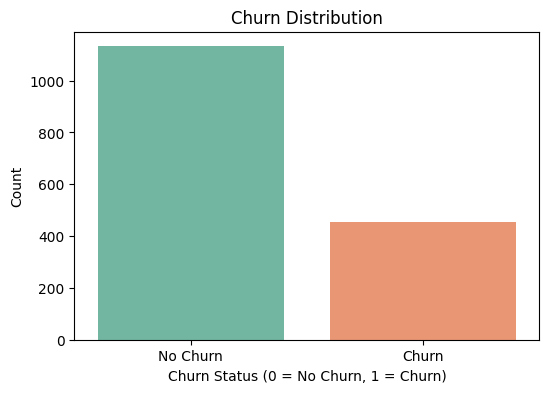

In [19]:
# check if the dataset is balanced or not
churn_counts = df_engineered['is_churn'].value_counts()
print(f"\nChurn distribution:\n{churn_counts}")
plt.figure(figsize=(6, 4))
sns.barplot(x=churn_counts.index, y=churn_counts.values, palette='Set2')
plt.title('Churn Distribution')
plt.xlabel('Churn Status (0 = No Churn, 1 = Churn)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.show()

In [20]:
# handle class imbalance with SMOTE
from imblearn.over_sampling import SMOTE
X = df_engineered[selected_features]
y = df_engineered['is_churn']
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print(f"\nAfter SMOTE resampling: {pd.Series(y_resampled).value_counts()}")


After SMOTE resampling: is_churn
0    1132
1    1132
Name: count, dtype: int64


In [21]:
# model comparison using selected features with lazyclassifier
from lazypredict.Supervised import LazyClassifier
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)
print(models)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 906, number of negative: 905
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000271 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1733
[LightGBM] [Info] Number of data points in the train set: 1811, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500276 -> initscore=0.001104
[LightGBM] [Info] Start training from score 0.001104
                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  \
Model                                                                           
ExtraTreesClassifier               0.79               0.79     0.79      0.79   
LGBMClassifier                     0.78               0.78     0.78      0.78   
RandomForestClassifier             0.77               0.77     0.77      0.77   
BaggingClassifier                  0.77      

In [22]:
# hyperparameter tuning for extra trees model using optuna
from sklearn.ensemble import ExtraTreesClassifier
import optuna
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 5, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    }
    model = ExtraTreesClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, y_pred_proba)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
print(f"\nBest hyperparameters: {study.best_params}")
best_model = ExtraTreesClassifier(**study.best_params, random_state=42)
best_model.fit(X_train, y_train)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"Optimized Extra Trees AUC: {auc_score:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, best_model.predict(X_test)))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, best_model.predict(X_test)))



[I 2026-04-12 14:54:15,679] A new study created in memory with name: no-name-9e7135f5-33d2-4a03-b0ad-f47bab612764
[I 2026-04-12 14:54:15,771] Trial 0 finished with value: 0.6977505750263149 and parameters: {'n_estimators': 206, 'max_depth': 43, 'min_samples_split': 9, 'min_samples_leaf': 20, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6977505750263149.
[I 2026-04-12 14:54:16,010] Trial 1 finished with value: 0.730049510740322 and parameters: {'n_estimators': 566, 'max_depth': 38, 'min_samples_split': 13, 'min_samples_leaf': 16, 'max_features': 'log2'}. Best is trial 1 with value: 0.730049510740322.
[I 2026-04-12 14:54:16,103] Trial 2 finished with value: 0.7341624108221901 and parameters: {'n_estimators': 218, 'max_depth': 40, 'min_samples_split': 11, 'min_samples_leaf': 15, 'max_features': 'log2'}. Best is trial 2 with value: 0.7341624108221901.
[I 2026-04-12 14:54:16,343] Trial 3 finished with value: 0.84975244629839 and parameters: {'n_estimators': 372, 'max_depth': 30, '


Best hyperparameters: {'n_estimators': 180, 'max_depth': 33, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Optimized Extra Trees AUC: 0.8697

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.82       227
           1       0.83      0.78      0.80       226

    accuracy                           0.81       453
   macro avg       0.81      0.81      0.81       453
weighted avg       0.81      0.81      0.81       453


Confusion Matrix:
[[190  37]
 [ 49 177]]


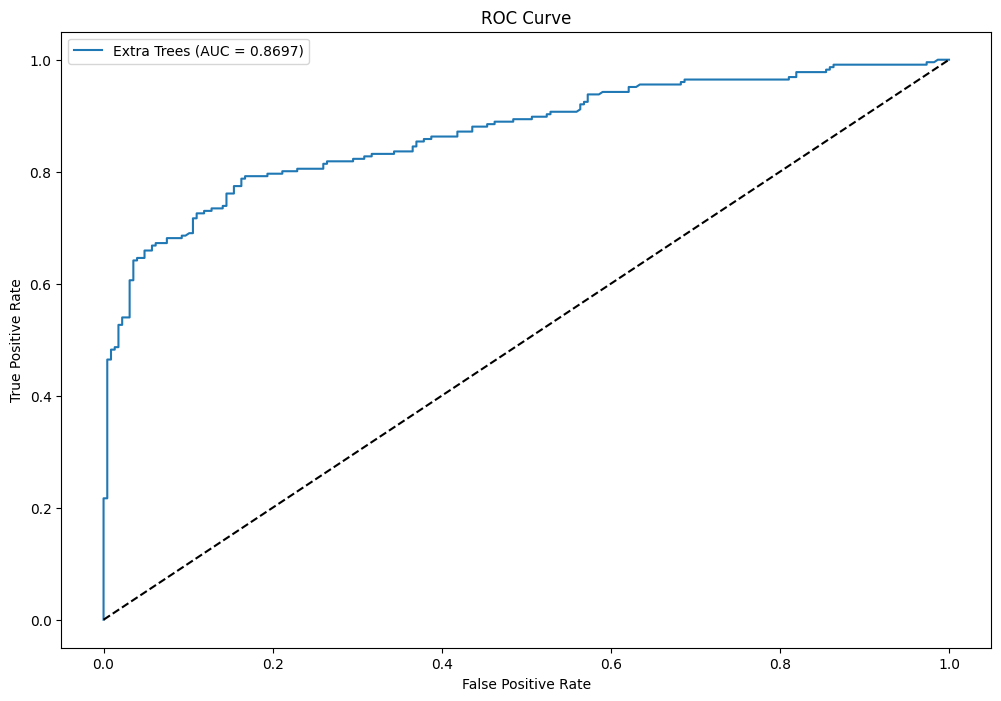

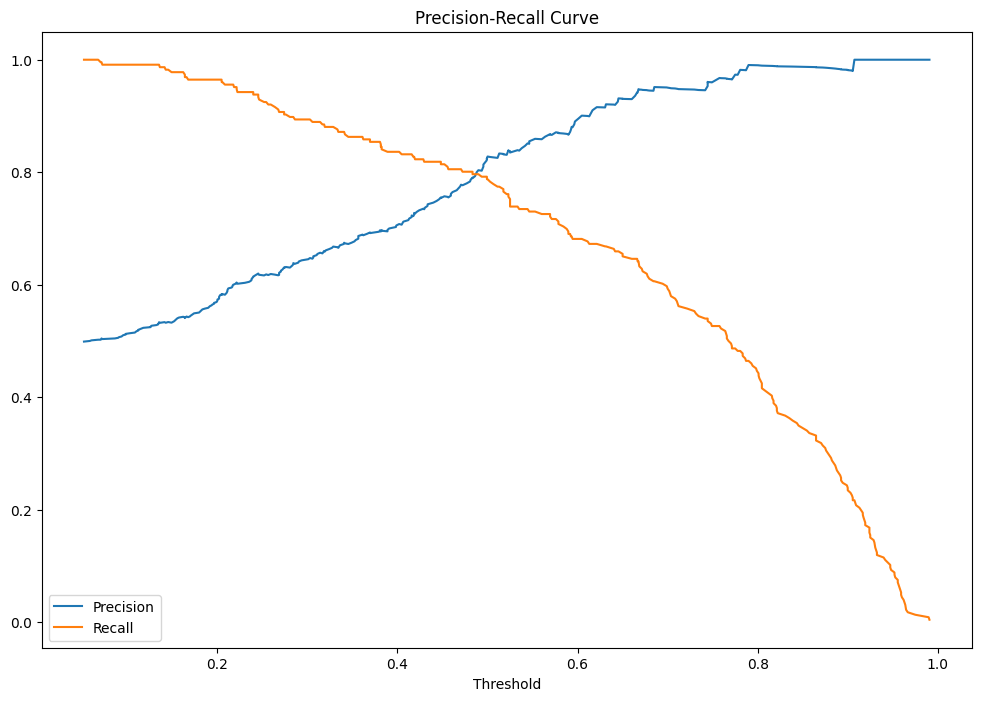


Best threshold based on precision-recall curve: 0.4993


In [26]:
#plot auc curve for the optimized model and find hte best threshold for classification based on the precision-recall curve
from sklearn.metrics import roc_curve, precision_recall_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(12, 8))
plt.plot(fpr, tpr, label=f'Extra Trees (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()  
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(12, 8))
plt.plot(pr_thresholds, precision[:-1], label='Precision')
plt.plot(pr_thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()
print(f"\nBest threshold based on precision-recall curve: {pr_thresholds[np.argmax(precision[:-1] * recall[:-1])]:.4f}")

In [24]:
# feature importance analysis for the optimized model
importances = best_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
print(f"\n--- Feature Importances ---")
print(feature_importance_df)


--- Feature Importances ---
                        Feature  Importance
4  preferred_category_churn_enc        0.18
3            purchase_intensity        0.15
0    country_category_churn_enc        0.15
7                 clv_proxy_log        0.13
1             country_churn_enc        0.12
8               total_spend_log        0.12
5        monetary_concentration        0.12
6          is_high_risk_country        0.01
2                 is_whale_risk        0.01
